V1 (02 11 2025): Translated from R to Python and added the visualizations for goals B to D

In [441]:
#!pip install numpy pandas scipy matplotlib

In [442]:
import numpy as np
from scipy.stats import norm
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os
import subprocess
import openpyxl

# Define Functions
This section defines the functions used for calculating portfolio volatility, expected return, 
goal achievement probability, and the objective (failure probability) to minimize.

In [443]:

def sd_f(weight_vector, covar_table):
    covar_vector = np.zeros(len(weight_vector))
    for z in range(len(weight_vector)):
        covar_vector[z] = np.sum(weight_vector * covar_table[:, z])
    return np.sqrt(np.sum(weight_vector * covar_vector))

In [444]:
def mean_f(weight_vector, return_vector):
    return np.sum(weight_vector * return_vector)

In [445]:
def phi_f(goal_vector, goal_allocation, pool, mean, sd):
    # goal_vector is [value ratio, funding requirement, time horizon]
    required_return = (goal_vector[1] / (pool * goal_allocation))**(1 / goal_vector[2]) - 1
    if goal_allocation * pool >= goal_vector[1]:
        return 1
    else:
        return 1 - norm.cdf(required_return, loc=mean, scale=sd)

In [446]:
def optim_function(weights):
    # Uses the current global variables: goal_vector, allocation, pool, return_vector, covar_table
    return 1 - phi_f(
        goal_vector,
        allocation,
        pool,
        mean_f(weights, return_vector),
        sd_f(weights, covar_table)
    )

In [447]:
def constraint_function(weights):
    # For SciPy equality constraints, we require constraint_function(weights) == 0.
    return np.sum(weights) - 1

In [448]:
def mvu_f(weights):
    # mvu_f is defined for mean-variance optimization (not used below).
    return -(mean_f(weights, return_vector) - 0.5 * gamma * sd_f(weights, covariances)**2)

In [449]:
def r_req_f(goal_vector, goal_allocation, pool):
    return (goal_vector[1] / (goal_allocation * pool))**(1 / goal_vector[2]) - 1

# Load & Parse Data

In [450]:
# -- Variable Setup -- ##

#Monte Carlo Trials
n_trials = 10**5

#Case Study Profile Selection
Profile = "P1" #Either P1 or P2

#Excel worksheets
excel_returns = "Returns"
excel_volatilities = "Volatilities"
excel_correlation = "Correlation"
excel_gbi = "GBI Allocations P1" if Profile == "P1" else "GBI Allocations P2"
excel_gbi_goals = "GBI Goals P1" if Profile == "P1" else "GBI Goals P2"

# Total pool of wealth
pool = 4654000

In [451]:
## -- Repo Root and Folders -- ##

# Get repo root and set folders
root = subprocess.run(["git", "rev-parse", "--show-toplevel"], capture_output=True, text=True).stdout.strip()
data_folder = os.path.join(root, "GBI Optimisation", "data")
output_folder = os.path.join(root, "GBI Optimisation")

# Get excel file and sheets
master_excel_path = os.path.join(data_folder, "Master.xlsx")

df_returns = pd.read_excel(master_excel_path, sheet_name=excel_returns)
df_vols = pd.read_excel(master_excel_path, sheet_name=excel_volatilities)

df_returns.set_index(df_returns.columns[0], inplace=True)
df_vols.set_index(df_vols.columns[0], inplace=True)

df_corr = pd.read_excel(master_excel_path, sheet_name=excel_correlation)
df_corr.set_index(df_corr.columns[0], inplace=True)

print(df_corr)


BadZipFile: File is not a zip file

In [411]:
## -- Loop Table -- ##
table_loop_df = pd.read_excel(master_excel_path, sheet_name="Loop",usecols="B:F",skiprows=1,header=0)

# Find Last looped year and select the next one
# Filter only rows where LoopStatus is N
pending_rows = table_loop_df[table_loop_df["LoopStatus"] == "N"]

# If we find any rows, get the row with the lowest Year
if not pending_rows.empty:
    chosen_row = pending_rows.loc[pending_rows["Year"].idxmin()]

    # Extract needed columns
    loop_year = chosen_row["Year"]
    loop_number = chosen_row["N"]
    loop_age1 = chosen_row["AgeP1"]
    loop_age2 = chosen_row["AgeP2"]

    print(loop_year, loop_number, loop_age1, loop_age2)
else:
    print("All loops completed")


2026 2 26 41


In [412]:
capital_market_expectations_raw = {}
for asset in df_returns.index:
    expected_return = df_returns.loc[asset, str(loop_year)]
    volatility = df_vols.loc[asset, 'volatility']
    capital_market_expectations_raw[asset] = {
        'Return Forecast': expected_return,
        'Volatility Forecast': volatility
    }

capital_market_expectations_raw = pd.DataFrame.from_dict(capital_market_expectations_raw, orient='index')

capital_market_expectations_raw = capital_market_expectations_raw.reset_index()
capital_market_expectations_raw.rename(columns={'index': 'Unnamed: 0'}, inplace=True)

# Rearrange columns to match your old format (optional):
capital_market_expectations_raw = capital_market_expectations_raw[['Unnamed: 0', 'Return Forecast', 'Volatility Forecast']]

print(capital_market_expectations_raw)

                             Unnamed: 0  Return Forecast  Volatility Forecast
0           Emerging Markets - Equities         0.251939                0.086
1          Developed Markets - Equities         0.195111                0.070
2  Emerging Markets State - Obligations         0.179000                0.049
3        High Yield Bonds - Obligations         0.168635                0.050
4  Investment Grade Bonds - Obligations         0.174071                0.037
5     Government ZC Bonds - Obligations         0.103101                0.029


In [413]:
def get_goal_data(master_excel_path, plan=Profile):
    """
    Returns a DataFrame of the specified goal table (P1 or P2).
    P1 => B2:F5
    P2 => B7:F10
    """
    if plan == "P1":
        skip = 1  # start reading at row 2
    elif plan == "P2":
        skip = 6  # start reading at row 7
    else:
        raise ValueError("Plan not recognized. Use 'P1' or 'P2'.")

    df_goals = pd.read_excel(master_excel_path,sheet_name="Goals",skiprows=skip,nrows=4,usecols="B:F",header=0)
    # First column is "Goal Info", so make that the index
    df_goals.set_index(df_goals.columns[0], inplace=True)
    return df_goals

goal_data_raw = get_goal_data(master_excel_path, plan="P1")

print(goal_data_raw)

                      GOAL A      GOAL B    GOAL C      GOAL D
Goal Info                                                     
Value Ratio                1        0.45       0.5        0.58
Funding Requirement  5157000  5000000.00  713500.0  8812000.00
Time Horizon              10       30.00       4.0       18.00


In [414]:
# Record number of potential investments and goals
num_assets = capital_market_expectations_raw.shape[0]
num_goals = goal_data_raw.shape[1]

# Create vector of expected returns
return_vector = capital_market_expectations_raw["Return Forecast"].to_numpy()

# Get the correlations as a numeric DataFrame (just a num_assets × num_assets block)
correlations = df_corr.iloc[:num_assets, :num_assets].astype(float)

# Build the covariance matrix: stdev_i * stdev_j * correlation_ij
stdevs = capital_market_expectations_raw["Volatility Forecast"].to_numpy()
covariances = np.zeros((num_assets, num_assets))
for i in range(num_assets):
    for j in range(num_assets):
        covariances[i, j] = stdevs[i] * stdevs[j] * correlations.iloc[i, j]


# Parse Goal Data
Each goal vector is of the form: [value ratio, funding requirement, time horizon]

In [415]:
print(goal_data_raw)

                      GOAL A      GOAL B    GOAL C      GOAL D
Goal Info                                                     
Value Ratio                1        0.45       0.5        0.58
Funding Requirement  5157000  5000000.00  713500.0  8812000.00
Time Horizon              10       30.00       4.0       18.00


In [416]:
goal_A = goal_data_raw["GOAL A"].values
goal_B = goal_data_raw["GOAL B"].values
goal_C = goal_data_raw["GOAL C"].values
goal_D = goal_data_raw["GOAL D"].values


# Step 1: Optimal Within-Goal Allocation
Enumerate possible across-goal allocations (from 0.01 to 1)
and, for each goal, optimize the subportfolio weights.

In [417]:

goal_allocation = np.arange(0.01, 1.01, 0.01)

# Starting weights (random initialization normalized to sum to 1)
starting_weights = np.random.uniform(0, 1, num_assets)
starting_weights /= np.sum(starting_weights)

# Initialize matrices to store the optimal weights for each goal
optimal_weights_A = np.zeros((len(goal_allocation), num_assets))
optimal_weights_B = np.zeros((len(goal_allocation), num_assets))
optimal_weights_C = np.zeros((len(goal_allocation), num_assets))
optimal_weights_D = np.zeros((len(goal_allocation), num_assets))

In [418]:
goal_allocation = np.arange(0.01, 1.01, 0.01)

# Starting weights (random initialization normalized to sum to 1)
starting_weights = np.random.uniform(0, 1, num_assets)
starting_weights /= np.sum(starting_weights)

# Initialize matrices to store the optimal weights for each goal
optimal_weights_A = np.zeros((len(goal_allocation), num_assets))
optimal_weights_B = np.zeros((len(goal_allocation), num_assets))
optimal_weights_C = np.zeros((len(goal_allocation), num_assets))
optimal_weights_D = np.zeros((len(goal_allocation), num_assets))

# Set SLSQP options to be more stringent, mimicking solnp's behavior.
slsqp_opts = {
    'ftol': 1e-12,     # function tolerance
    'eps': 1e-12,      # finite-difference step size for gradient estimation
    'maxiter': 10000,  # maximum iterations
    'disp': False     # do not display convergence messages
}

for i, alloc in enumerate(goal_allocation):
    allocation = alloc      # Global variable used in optim_function
    covar_table = covariances

    # Goal A Optimization
    goal_vector = goal_A   # Global variable used in optim_function
    if goal_A[1] <= pool * allocation:
        optimal_weights_A[i, :] = [0]*(num_assets - 1) + [1]
    else:
        result = minimize(
            optim_function,
            starting_weights,
            constraints=[{'type': 'eq', 'fun': constraint_function}],
            bounds=[(0, 1)] * num_assets,
            method='SLSQP',
            options=slsqp_opts
        )
        optimal_weights_A[i, :] = result.x

    # Goal B Optimization
    goal_vector = goal_B
    if goal_B[1] <= pool * allocation:
        optimal_weights_B[i, :] = [0]*(num_assets - 1) + [1]
    else:
        result = minimize(
            optim_function,
            starting_weights,
            constraints=[{'type': 'eq', 'fun': constraint_function}],
            bounds=[(0, 1)] * num_assets,
            method='SLSQP',
            options=slsqp_opts
        )
        optimal_weights_B[i, :] = result.x

    # Goal C Optimization
    goal_vector = goal_C
    if goal_C[1] <= pool * allocation:
        optimal_weights_C[i, :] = [0]*(num_assets - 1) + [1]
    else:
        result = minimize(
            optim_function,
            starting_weights,
            constraints=[{'type': 'eq', 'fun': constraint_function}],
            bounds=[(0, 1)] * num_assets,
            method='SLSQP',
            options=slsqp_opts
        )
        optimal_weights_C[i, :] = result.x

    # Goal D Optimization
    goal_vector = goal_D
    if goal_D[1] <= pool * allocation:
        optimal_weights_D[i, :] = [0]*(num_assets - 1) + [1]
    else:
        result = minimize(
            optim_function,
            starting_weights,
            constraints=[{'type': 'eq', 'fun': constraint_function}],
            bounds=[(0, 1)] * num_assets,
            method='SLSQP',
            options=slsqp_opts
        )
        optimal_weights_D[i, :] = result.x

In [419]:
# Calculate the best probability (phi) for each allocation level for every goal
phi_A = np.zeros(len(goal_allocation))
phi_B = np.zeros(len(goal_allocation))
phi_C = np.zeros(len(goal_allocation))
phi_D = np.zeros(len(goal_allocation))

for i, alloc in enumerate(goal_allocation):
    phi_A[i] = phi_f(goal_A, alloc, pool,
                     mean_f(optimal_weights_A[i, :], return_vector),
                     sd_f(optimal_weights_A[i, :], covariances))
    phi_B[i] = phi_f(goal_B, alloc, pool,
                     mean_f(optimal_weights_B[i, :], return_vector),
                     sd_f(optimal_weights_B[i, :], covariances))
    phi_C[i] = phi_f(goal_C, alloc, pool,
                     mean_f(optimal_weights_C[i, :], return_vector),
                     sd_f(optimal_weights_C[i, :], covariances))
    phi_D[i] = phi_f(goal_D, alloc, pool,
                     mean_f(optimal_weights_D[i, :], return_vector),
                     sd_f(optimal_weights_D[i, :], covariances))

# Step 2: Optimal Across-Goal Allocation
Simulate goal weights and compute utility for each trial.

In [420]:
# Simulate goal weights: each row is a simulated allocation (in percentages)
sim_goal_weights = np.zeros((n_trials, num_goals), dtype=int)
for i in range(n_trials):
    rand_vector = np.random.uniform(0, 1, num_goals)
    normalizer = np.sum(rand_vector)
    # Compute rounded percentages and enforce a minimum of 1
    percents = np.round((rand_vector / normalizer) * 100, 0)
    sim_goal_weights[i, :] = np.maximum(percents, 1)


# Calculate utility for each simulated portfolio.
# Note: subtract 1 from simulated weights for 0-indexing.
utility = (
    goal_A[0] * phi_A[sim_goal_weights[:, 0] - 1] +
    goal_A[0] * goal_B[0] * phi_B[sim_goal_weights[:, 1] - 1] +
    goal_A[0] * goal_B[0] * goal_C[0] * phi_C[sim_goal_weights[:, 2] - 1] +
    goal_A[0] * goal_B[0] * goal_C[0] * goal_D[0] * phi_D[sim_goal_weights[:, 3] - 1]
)

# Find the index of the portfolio with the highest utility
index = np.argmax(utility)
optimal_goal_weights = sim_goal_weights[index, :]

# Step 3: Optimal Subportfolios & Aggregate Portfolio
Retrieve the optimal subportfolio allocations and compute the aggregate portfolio.

In [421]:
# Retrieve optimal subportfolio allocations
optimal_subportfolios = np.zeros((num_goals, num_assets))
goals = ["A", "B", "C", "D"]

# For each goal, use the simulated percentage to select the corresponding row 
# from the optimal weights matrix (adjust for zero-indexing)
for i in range(num_goals):
    optimal_subportfolios[i, :] = eval(f"optimal_weights_{goals[i]}")[optimal_goal_weights[i] - 1, :]

# Compute the optimal aggregate investment portfolio.
optimal_aggregate_portfolio = (optimal_goal_weights / 100) @ optimal_subportfolios


# Visualize Results
Plot the Goal A subportfolio allocation as a function of the across-goal allocation.

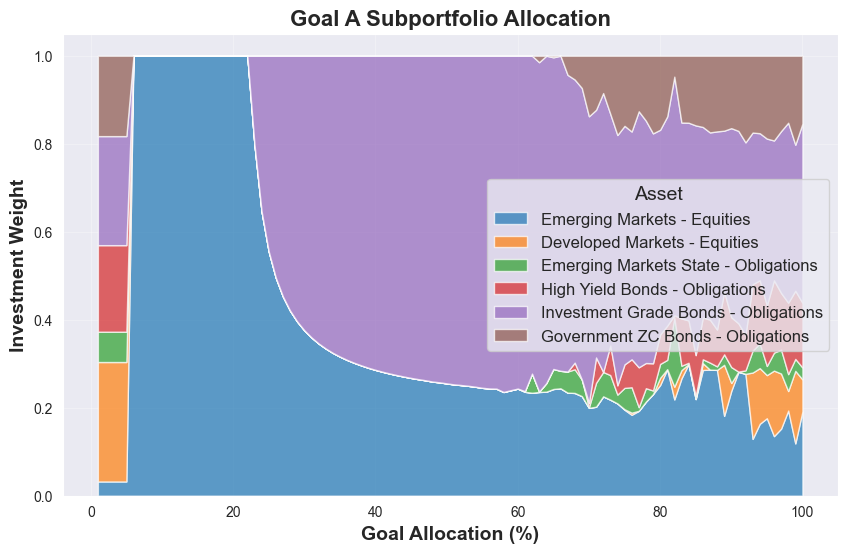

In [422]:

# Asset names from the first column of the capital market expectations
asset_names = capital_market_expectations_raw.iloc[:, 0].astype(str).tolist()

# Use stackplot to display the Goal A subportfolio allocation (stacked areas) versus goal allocation (in %)
plt.figure(figsize=(10, 6))
plt.stackplot(goal_allocation * 100, optimal_weights_A.T, labels=asset_names, alpha=0.7)
plt.xlabel("Goal Allocation (%)", fontsize=14, fontweight='bold')
plt.ylabel("Investment Weight", fontsize=14, fontweight='bold')
plt.title("Goal A Subportfolio Allocation", fontsize=16, fontweight='bold')
plt.legend(title="Asset", fontsize=12, title_fontsize=14)
plt.grid(alpha=0.3)
plt.show()

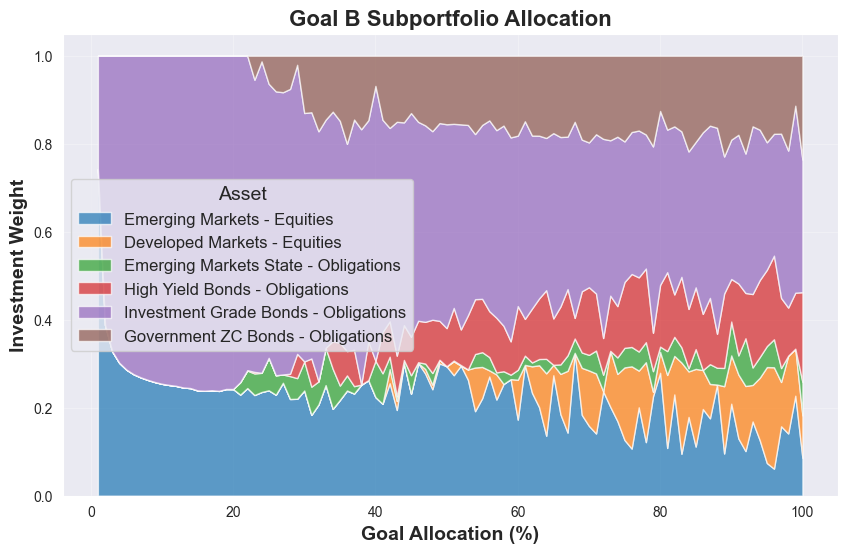

In [423]:
# Asset names from the first column of the capital market expectations
asset_names = capital_market_expectations_raw.iloc[:, 0].astype(str).tolist()

# Use stackplot to display the Goal A subportfolio allocation (stacked areas) versus goal allocation (in %)
plt.figure(figsize=(10, 6))
plt.stackplot(goal_allocation * 100, optimal_weights_B.T, labels=asset_names, alpha=0.7)
plt.xlabel("Goal Allocation (%)", fontsize=14, fontweight='bold')
plt.ylabel("Investment Weight", fontsize=14, fontweight='bold')
plt.title("Goal B Subportfolio Allocation", fontsize=16, fontweight='bold')
plt.legend(title="Asset", fontsize=12, title_fontsize=14)
plt.grid(alpha=0.3)
plt.show()

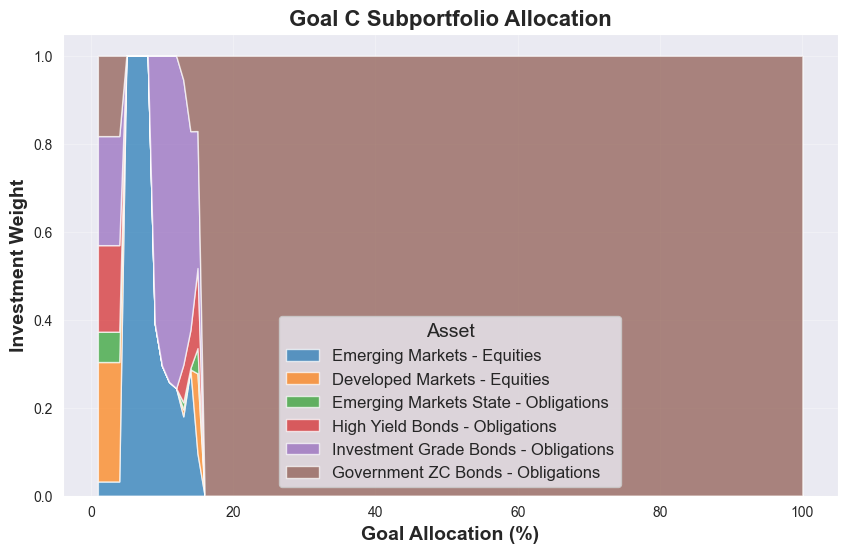

In [424]:
# Asset names from the first column of the capital market expectations
asset_names = capital_market_expectations_raw.iloc[:, 0].astype(str).tolist()

# Use stackplot to display the Goal A subportfolio allocation (stacked areas) versus goal allocation (in %)
plt.figure(figsize=(10, 6))
plt.stackplot(goal_allocation * 100, optimal_weights_C.T, labels=asset_names, alpha=0.7)
plt.xlabel("Goal Allocation (%)", fontsize=14, fontweight='bold')
plt.ylabel("Investment Weight", fontsize=14, fontweight='bold')
plt.title("Goal C Subportfolio Allocation", fontsize=16, fontweight='bold')
plt.legend(title="Asset", fontsize=12, title_fontsize=14)
plt.grid(alpha=0.3)
plt.show()

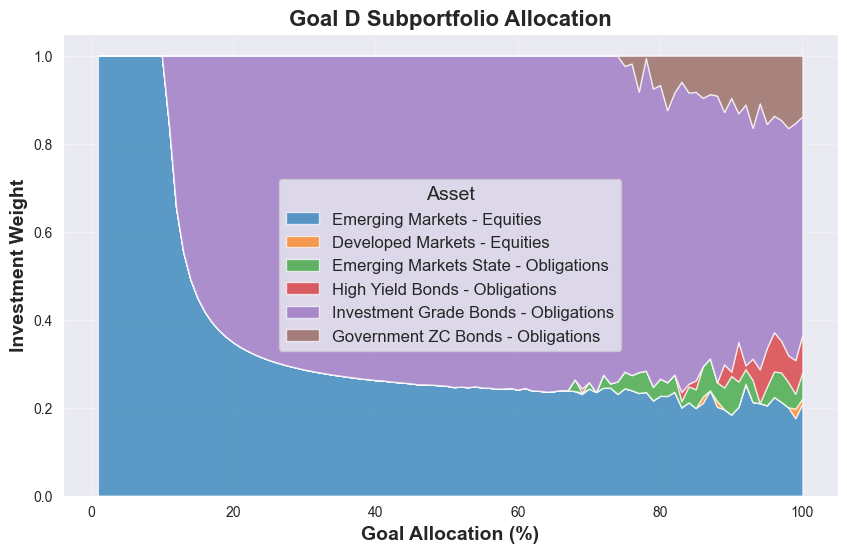

In [425]:
# Asset names from the first column of the capital market expectations
asset_names = capital_market_expectations_raw.iloc[:, 0].astype(str).tolist()

# Use stackplot to display the Goal A subportfolio allocation (stacked areas) versus goal allocation (in %)
plt.figure(figsize=(10, 6))
plt.stackplot(goal_allocation * 100, optimal_weights_D.T, labels=asset_names, alpha=0.7)
plt.xlabel("Goal Allocation (%)", fontsize=14, fontweight='bold')
plt.ylabel("Investment Weight", fontsize=14, fontweight='bold')
plt.title("Goal D Subportfolio Allocation", fontsize=16, fontweight='bold')
plt.legend(title="Asset", fontsize=12, title_fontsize=14)
plt.grid(alpha=0.3)
plt.show()

# Print Results

In [426]:
print("Optimal Across-Goal Allocation:")
print(optimal_goal_weights)

print("\nOptimal Aggregate Investment Allocation:")
print(optimal_aggregate_portfolio)

Optimal Across-Goal Allocation:
[50  8 12 31]

Optimal Aggregate Investment Allocation:
[2.66006755e-01 1.30386772e-18 5.04685678e-17 6.95918064e-18
 7.43993245e-01 2.45425485e-18]


In [427]:
# Create a DataFrame for the across-goal allocation.
df_across_goal = pd.DataFrame({
    "Goal": goals,
    "Allocation (%)": optimal_goal_weights
})

# Create a DataFrame for the aggregate portfolio.
# Multiply the weight by 100 to display percentages.
df_aggregate = pd.DataFrame({
    "Asset": asset_names,
    "Weight": optimal_aggregate_portfolio,
    "Allocation (%)": np.round(optimal_aggregate_portfolio * 100, 2)
})

print("Optimal Across-Goal Allocation:")
print(df_across_goal.to_string(index=False))

print("\nOptimal Aggregate Investment Allocation:")
print(df_aggregate.to_string(index=False))


Optimal Across-Goal Allocation:
Goal  Allocation (%)
   A              50
   B               8
   C              12
   D              31

Optimal Aggregate Investment Allocation:
                               Asset       Weight  Allocation (%)
         Emerging Markets - Equities 2.660068e-01            26.6
        Developed Markets - Equities 1.303868e-18             0.0
Emerging Markets State - Obligations 5.046857e-17             0.0
      High Yield Bonds - Obligations 6.959181e-18             0.0
Investment Grade Bonds - Obligations 7.439932e-01            74.4
   Government ZC Bonds - Obligations 2.454255e-18             0.0


In [428]:
# Determine the correct worksheet based on the profile

# Load the Excel workbook and the relevant sheet
wb = openpyxl.load_workbook(master_excel_path)
ws = wb[excel_gbi]

# Find the column that matches loop_year
# Assume years start in column B (index 2) and row 1 has the year headers
year_col = None
for col in range(2, ws.max_column + 1):
    cell_value = ws.cell(row=1, column=col).value
    if cell_value == str(loop_year):
        year_col = col
        break

if year_col is None:
    raise ValueError(f"Year {loop_year} not found in worksheet headers.")

# Write each allocation to the appropriate asset row (rows 2 to 7 for assets A2 to A7)
for i, asset in enumerate(asset_names):
    allocation = float(np.round(optimal_aggregate_portfolio[i] * 100, 2))
    row = i + 2  # A2 is row 2
    ws.cell(row=row, column=year_col, value=allocation)


In [429]:
# Determine the correct worksheet for across-goal allocations
ws_goals = wb[excel_gbi_goals]

# Find the column in the goal sheet that matches loop_year
goal_year_col = None
for col in range(2, ws_goals.max_column + 1):
    cell_value = ws_goals.cell(row=1, column=col).value
    if str(cell_value).strip() == str(loop_year):
        goal_year_col = col
        break

if goal_year_col is None:
    raise ValueError(f"Year {loop_year} not found in goal worksheet headers.")

# Write each across-goal allocation to the appropriate row
for i, allocation in enumerate(df_across_goal["Allocation (%)"]):
    value = float(np.round(allocation, 6))  # keep precision
    row = i + 2  # assuming goals start at row 2
    cell = ws_goals.cell(row=row, column=goal_year_col, value=value)
    cell.number_format = '0.00%'  # percentage format

# Save the workbook again
wb.save(master_excel_path)

ValueError: I/O operation on closed file.